In [7]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import cv2
import keras
from numpy import random
import tensorflow as tf
import tensorflow_datasets as tfds
from matplotlib import pyplot as plt
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from keras.layers import Input, concatenate, GlobalAveragePooling2D  # Thêm GlobalAveragePooling2D
from keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split, KFold
import seaborn as sns
import os

In [2]:
# Định nghĩa thư mục và tham số
train_folder = "/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/train"
valid_folder = "/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/valid"
test_folder = "/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/test"
input_shape = (224,224,3)
num_classes = 4
epochs = 100
batch_size = 64

In [3]:
# Data Generators
train_datagen = ImageDataGenerator(
    dtype='float32',
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)
val_datagen = ImageDataGenerator(dtype='float32')
test_datagen = ImageDataGenerator(dtype='float32')

In [4]:
# Định nghĩa Inception Module (cơ bản của GoogLeNet)
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3,
                     filters_5x5_reduce, filters_5x5, filters_pool_proj):
    # 1x1 conv branch
    conv_1x1 = Conv2D(filters_1x1, (1, 1), padding='same', activation='relu')(x)

    # 3x3 conv branch
    conv_3x3 = Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu')(x)
    conv_3x3 = Conv2D(filters_3x3, (3, 3), padding='same', activation='relu')(conv_3x3)

    # 5x5 conv branch
    conv_5x5 = Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu')(x)
    conv_5x5 = Conv2D(filters_5x5, (5, 5), padding='same', activation='relu')(conv_5x5)

    # Max pooling branch
    pool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = Conv2D(filters_pool_proj, (1, 1), padding='same', activation='relu')(pool)

    # Concatenate các nhánh
    output = concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=-1)
    return output

# Hàm xây dựng mô hình GoogLeNet
def build_model():
    input_tensor = Input(shape=input_shape)

    # Lớp đầu vào
    x = Conv2D(64, (7, 7), strides=(2, 2), padding='same', activation='relu')(input_tensor)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)

    x = Conv2D(64, (1, 1), padding='same', activation='relu')(x)
    x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Thêm một số Inception modules
    x = inception_module(x, 64, 96, 128, 16, 32, 32)
    x = inception_module(x, 128, 128, 192, 32, 96, 64)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = inception_module(x, 192, 96, 208, 16, 48, 64)
    x = inception_module(x, 160, 112, 224, 24, 64, 64)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Global Average Pooling
    x = GlobalAveragePooling2D()(x)

    # Fully connected layers
    x = Dense(1024, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    # Tạo model
    model = Model(inputs=input_tensor, outputs=predictions)

    # Compile model
    optimizer = tf.keras.optimizers.SGD()
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Định nghĩa Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Theo dõi validation loss
    patience=10,          # Dừng sau 10 epochs nếu không cải thiện
    verbose=1,           # In thông báo khi dừng
    restore_best_weights=True  # Khôi phục trọng số tốt nhất
)

In [5]:
# Tạo generators cho chạy đơn
print("=== Bắt đầu chạy đơn ===")
train_generator = train_datagen.flow_from_directory(
    train_folder,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='categorical',
)

validation_generator = val_datagen.flow_from_directory(
    valid_folder,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='categorical',
)

test_generator = test_datagen.flow_from_directory(
    test_folder,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
)

=== Bắt đầu chạy đơn ===
Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 112, 112,  │      9,472 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 56, 56,    │          0 │ conv2d_27[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ max_pooling2d_8[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 56, 56,    │      4,160 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 56, 56,    │    110,784 │ conv2d_28[0][0]   │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        768 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 28, 28,    │     18,528 │ max_pooling2d_9[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 28, 28,    │      3,088 │ max_pooling2d_9[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 28, 28,    │          0 │ max_pooling2d_9[… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 28, 28,    │     12,352 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 28, 28,    │    110,720 │ conv2d_31[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 28, 28,    │     12,832 │ conv2d_33[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 28, 28,    │      6,176 │ max_pooling2d_10… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 28, 28,    │          0 │ conv2d_30[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_32[0][0],  │
│                     │                   │            │ conv2d_34[0][0],  │
│                     │                   │            │ conv2d_35[0][0] 

 Total params: 2,555,372 (9.75 MB)

 Trainable params: 2,554,860 (9.75 MB)

 Non-trainable params: 512 (2.00 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 160s 14s/step - accuracy: 0.3078 - loss: 1.7505 - val_accuracy: 0.1806 - val_loss: 1.4634
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.4398 - loss: 1.2219 - val_accuracy: 0.1806 - val_loss: 1.4166
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5503 - loss: 1.0852 - val_accuracy: 0.1806 - val_loss: 1.5208
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6219 - loss: 0.9464 - val_accuracy: 0.1806 - val_loss: 1.5243
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5003 - loss: 1.0116 - val_accuracy: 0.1806 - val_loss: 1.4102
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5702 - loss: 0.9361 - val_accuracy: 0.1806 - val_loss: 1.4676
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5856 - loss: 0.9156 - val_accuracy: 0.1806 - val_loss: 1.4914
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5774 - loss: 0.9423 - val_accuracy: 0.1806 -

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


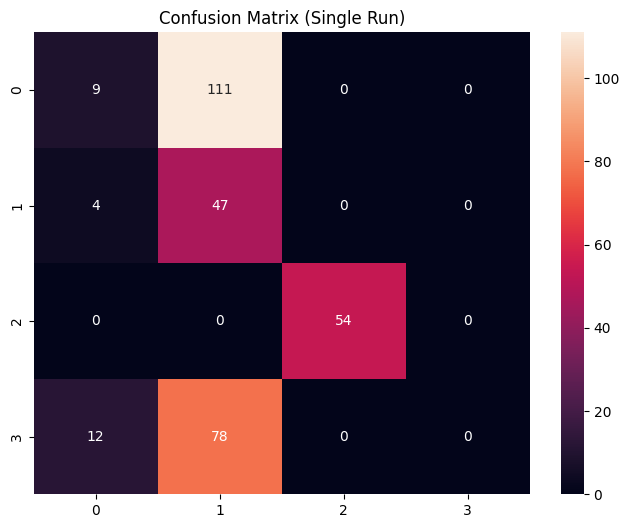

In [8]:
# Build and train model
model = build_model()
model.summary()

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    verbose=1,
    callbacks=[early_stopping]  # Thêm Early Stopping
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'Test accuracy (Single Run): {test_acc}')

# Detailed evaluation
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report and confusion matrix
print("Classification Report (Single Run):")
print(classification_report(y_true, y_pred_classes))
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Single Run)")
plt.show()

# Save model
model.save('/content/drive/MyDrive/KLTN/GoogleNet (InceptionV1)/model_GoogleNet_single.h5')

In [9]:
# K-Fold Cross-Validation (k=5)
print("\n=== Bắt đầu K-Fold Cross-Validation (k=5) ===")

# Chuẩn bị dữ liệu cho k-fold
all_data_folder = train_folder  # Sử dụng train_folder cho k-fold
all_generator = train_datagen.flow_from_directory(
    all_data_folder,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# Lấy tất cả dữ liệu
X = []
y = []
for i in range(len(all_generator)):
    batch_X, batch_y = all_generator[i]
    X.extend(batch_X)
    y.extend(batch_y)
X = np.array(X)
y = np.array(y)


=== Bắt đầu K-Fold Cross-Validation (k=5) ===
Found 613 images belonging to 4 classes.



Fold 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.2449 - loss: 1.9296 - val_accuracy: 0.2520 - val_loss: 1.4137
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 858ms/step - accuracy: 0.4543 - loss: 1.2434 - val_accuracy: 0.2520 - val_loss: 1.4680
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 672ms/step - accuracy: 0.4263 - loss: 1.1867 - val_accuracy: 0.2520 - val_loss: 1.5669
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 937ms/step - accuracy: 0.4705 - loss: 1.1178 - val_accuracy: 0.2520 - val_loss: 1.5210
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 714ms/step - accuracy: 0.5287 - loss: 1.0772 - val_accuracy: 0.2520 - val_loss: 1.4695
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 900ms/step - accuracy: 0.5511 - loss: 0.9675 - val_accuracy: 0.2520 - val_loss: 1.3865
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 661ms/step - accuracy: 0.5735 - loss: 0.9912 - val_accuracy: 0.2520 - val_loss: 1.3398
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 729ms/step - accuracy: 0.5759 - loss: 0.9329 - val_accuracy: 0.2520 - val

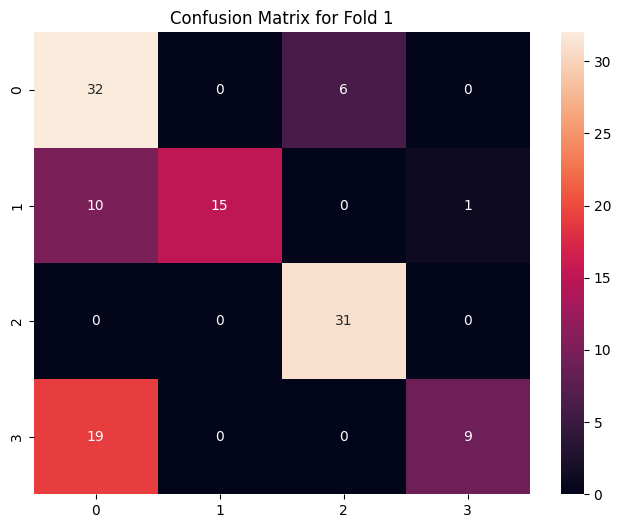


Fold 2/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.3197 - loss: 1.5544 - val_accuracy: 0.2683 - val_loss: 1.8051
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 664ms/step - accuracy: 0.3246 - loss: 1.3388 - val_accuracy: 0.2683 - val_loss: 1.5643
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 851ms/step - accuracy: 0.4882 - loss: 1.1470 - val_accuracy: 0.2683 - val_loss: 1.3482
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 700ms/step - accuracy: 0.4984 - loss: 1.0720 - val_accuracy: 0.2683 - val_loss: 1.6473
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4204 - loss: 1.2191 - val_accuracy: 0.2683 - val_loss: 1.5730
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 746ms/step - accuracy: 0.5007 - loss: 1.0933 - val_accuracy: 0.2683 - val_loss: 1.3823
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 833ms/step - accuracy: 0.5396 - loss: 0.9778 - val_accuracy: 0.2683 - val_loss: 1.4554
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 675ms/step - accuracy: 0.5522 - loss: 1.0000 - val_accuracy: 0.2683 - val_lo

1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step

Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.61      0.79      0.69        38
           1       0.61      0.77      0.68        22
           2       0.82      1.00      0.90        33
           3       0.83      0.17      0.28        30

    accuracy                           0.69       123
   macro avg       0.72      0.68      0.64       123
weighted avg       0.72      0.69      0.65       123



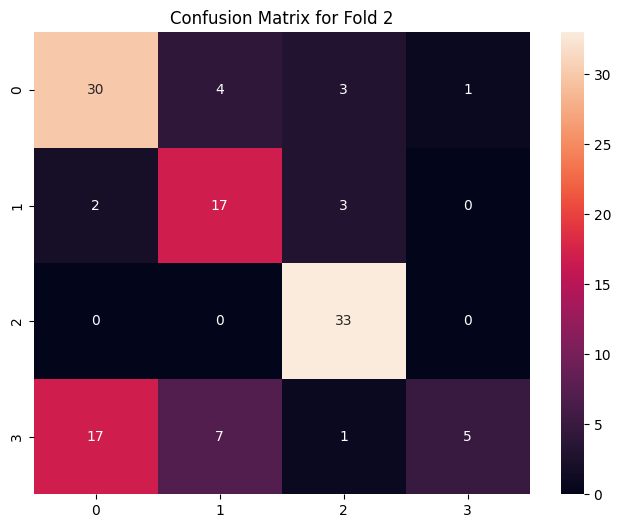


Fold 3/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.2598 - loss: 1.5298 - val_accuracy: 0.2439 - val_loss: 1.4519
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 806ms/step - accuracy: 0.2813 - loss: 1.3610 - val_accuracy: 0.2439 - val_loss: 1.4478
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 831ms/step - accuracy: 0.4104 - loss: 1.1955 - val_accuracy: 0.2439 - val_loss: 1.4027
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 657ms/step - accuracy: 0.4702 - loss: 1.1724 - val_accuracy: 0.2439 - val_loss: 1.5414
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 754ms/step - accuracy: 0.5486 - loss: 1.0829 - val_accuracy: 0.2602 - val_loss: 1.3038
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 678ms/step - accuracy: 0.4711 - loss: 1.1745 - val_accuracy: 0.2439 - val_loss: 1.4306
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 646ms/step - accuracy: 0.5881 - loss: 1.0083 - val_accuracy: 0.2439 - val_loss: 1.3679
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 800ms/step - accuracy: 0.5441 - loss: 1.0276 - val_accuracy: 0.2439 - va

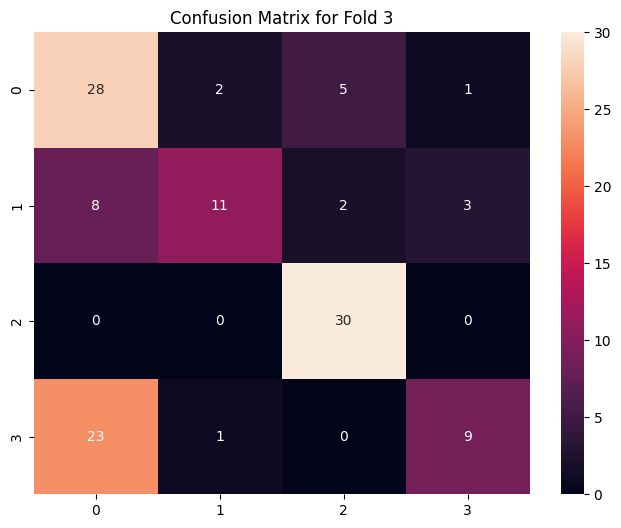


Fold 4/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.3036 - loss: 1.7231 - val_accuracy: 0.2049 - val_loss: 1.4426
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 775ms/step - accuracy: 0.5020 - loss: 1.2061 - val_accuracy: 0.2049 - val_loss: 1.5499
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 666ms/step - accuracy: 0.4962 - loss: 1.1391 - val_accuracy: 0.2049 - val_loss: 1.6221
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 853ms/step - accuracy: 0.5924 - loss: 1.0162 - val_accuracy: 0.2049 - val_loss: 1.6072
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 658ms/step - accuracy: 0.5871 - loss: 0.9476 - val_accuracy: 0.2131 - val_loss: 1.4415
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 853ms/step - accuracy: 0.4144 - loss: 1.1875 - val_accuracy: 0.2049 - val_loss: 1.7309
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 672ms/step - accuracy: 0.5839 - loss: 0.9606 - val_accuracy: 0.2049 - val_loss: 1.6213
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 855ms/step - accuracy: 0.5679 - loss: 0.9067 - val_accuracy: 0.2049 - va

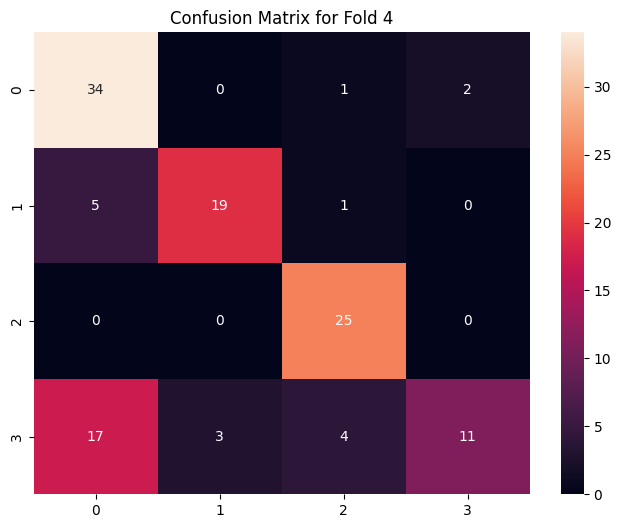


Fold 5/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.2572 - loss: 1.8370 - val_accuracy: 0.2377 - val_loss: 1.3436
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 837ms/step - accuracy: 0.4162 - loss: 1.2772 - val_accuracy: 0.2377 - val_loss: 1.7772
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 700ms/step - accuracy: 0.4180 - loss: 1.1650 - val_accuracy: 0.2377 - val_loss: 1.6984
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 939ms/step - accuracy: 0.4690 - loss: 1.1826 - val_accuracy: 0.2377 - val_loss: 1.3897
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 697ms/step - accuracy: 0.5087 - loss: 1.1057 - val_accuracy: 0.2377 - val_loss: 1.4285
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 840ms/step - accuracy: 0.5393 - loss: 1.0546 - val_accuracy: 0.2377 - val_loss: 1.4110
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 646ms/step - accuracy: 0.5532 - loss: 0.9823 - val_accuracy: 0.2377 - val_loss: 1.3645
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 870ms/step - accuracy: 0.4724 - loss: 1.0882 - val_accuracy: 0.2377 - val

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


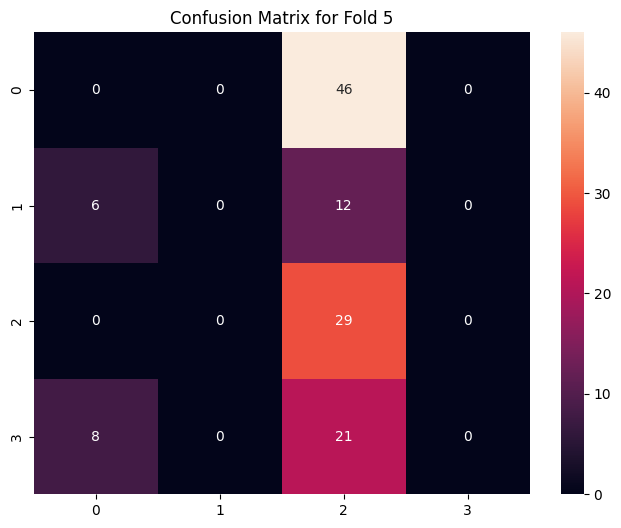


=== Kết quả K-Fold Cross-Validation ===
Average Accuracy: 0.5999 (+- 0.1839)
Average Loss: 0.8746 (+- 0.1977)


In [10]:
# K-Fold
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_no = 1
acc_per_fold = []
loss_per_fold = []

for train_index, val_index in kf.split(X):
    print(f'\nFold {fold_no}/{k}')

    # Chia dữ liệu
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Tạo data generators cho fold hiện tại
    train_gen = train_datagen.flow(
        X_train, y_train,
        batch_size=batch_size
    )
    val_gen = val_datagen.flow(
        X_val, y_val,
        batch_size=batch_size,
        shuffle=False  # Không shuffle để đánh giá chính xác
    )

    # Build and train model
    model = build_model()

    # Train
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        verbose=1,
        callbacks=[early_stopping]  # Thêm Early Stopping
    )

    # Evaluate
    scores = model.evaluate(val_gen, verbose=1)
    print(f'Score for fold {fold_no}: Loss = {scores[0]}; Accuracy = {scores[1]}')
    acc_per_fold.append(scores[1])
    loss_per_fold.append(scores[0])

    # Detailed evaluation for each fold
    y_val_true = np.argmax(y_val, axis=1)  # Chuyển one-hot encoding về nhãn
    y_val_pred = model.predict(val_gen)
    y_val_pred_classes = np.argmax(y_val_pred, axis=1)

    # Classification report for each fold
    print(f"\nClassification Report for Fold {fold_no}:")
    print(classification_report(y_val_true, y_val_pred_classes))

    # Confusion matrix for each fold
    cm = confusion_matrix(y_val_true, y_val_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix for Fold {fold_no}")
    plt.show()

    fold_no += 1

# Báo cáo kết quả K-Fold
print('\n=== Kết quả K-Fold Cross-Validation ===')
print(f'Average Accuracy: {np.mean(acc_per_fold):.4f} (+- {np.std(acc_per_fold):.4f})')
print(f'Average Loss: {np.mean(loss_per_fold):.4f} (+- {np.std(loss_per_fold):.4f})')

